# Práctica 2 — Análisis Exploratorio de Datos

En este notebook realizarás un **análisis exploratorio de datos (EDA)** sobre un
dataset de 240 estrellas clasificadas en 6 tipos.

**Dataset:** [Stars Dataset — Kaggle](https://www.kaggle.com/datasets/waqi786/stars-dataset)

## Instrucciones generales
- Cada sección tiene celdas marcadas con `# tu código aquí` — ahí debes escribir tu solución.
- Lee las instrucciones en cada celda de markdown **antes** de escribir el código.
- Consulta los enlaces a la documentación oficial para entender los parámetros de cada función.
- Ejecuta el notebook completo **sin errores** antes de hacer commit (`Kernel → Restart & Run All`).

## Contenido
1. [Importar librerías](#1.-Importar-librerías)
2. [Cargar los datos](#2.-Cargar-los-datos)
3. [Exploración inicial](#3.-Exploración-inicial)
4. [Distribución por tipo de estrella](#4.-Distribución-por-tipo-de-estrella)
5. [Temperatura por tipo](#5.-Temperatura-por-tipo-de-estrella)
6. [Luminosidad vs Temperatura](#6.-Luminosidad-vs-Temperatura)
7. [Estadísticas con NumPy](#7.-Estadísticas-con-NumPy)
8. [Diagrama Hertzsprung-Russell](#8.-Diagrama-Hertzsprung-Russell)

---
## Configuración del ambiente

Este proyecto usa **Poetry** para gestionar las dependencias. Antes de abrir el notebook
ejecuta estos comandos **desde la carpeta `practica2_analisis_datos/`**:

```bash
poetry install
poetry run jupyter notebook
```

---
## 1. Importar librerías

Importa las cuatro librerías con sus **alias convencionales**.
Estos alias son estándares en la comunidad — siempre se usan así:

| Librería | Alias | ¿Para qué sirve? | Documentación |
|---|---|---|---|
| `numpy` | `np` | Operaciones matemáticas vectorizadas sobre arrays | [numpy.org/doc/stable](https://numpy.org/doc/stable/user/whatisnumpy.html) |
| `pandas` | `pd` | Análisis y manipulación de datos tabulares (DataFrames) | [pandas.pydata.org/docs](https://pandas.pydata.org/docs/getting_started/index.html) |
| `matplotlib.pyplot` | `plt` | Visualización de datos (gráficas de bajo nivel) | [matplotlib.org/tutorials](https://matplotlib.org/stable/tutorials/index.html) |
| `seaborn` | `sns` | Visualización estadística de alto nivel (sobre matplotlib) | [seaborn.pydata.org/tutorial](https://seaborn.pydata.org/tutorial.html) |

**Sintaxis:** `import librería as alias`

In [1]:
# Importa las cuatro librerías con sus alias convencionales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Una vez que las importes, descomenta estas líneas para verificar las versiones:
print(f'numpy   {np.__version__}')
print(f'pandas  {pd.__version__}')
print(f'seaborn {sns.__version__}')

numpy   2.4.4
pandas  3.0.2
seaborn 0.13.2


---
## 2. Cargar los datos

Usa [`pd.read_csv()`](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html)
para leer el archivo CSV y cargarlo en un **DataFrame** de pandas.

- Revisa la documentación: ¿qué parámetro recibe `read_csv`? ¿qué devuelve?
- El archivo se encuentra en `'../data/star_dataset.csv'` (relativo a la carpeta `notebooks/`)
- Guarda el resultado en una variable llamada `stars`
- Después usa [`.head()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.head.html)
  para mostrar las primeras 5 filas

In [2]:
# Carga el archivo CSV con pd.read_csv() y guárdalo en 'stars'
# tu código aquí
stars = pd.read_csv('star_dataset.csv')

# Muestra las primeras 5 filas del DataFrame
# tu código aquí
stars.head()


,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,0,Red,M
1,3042,0.000500,0.1542,16.60,0,Red,M
2,2600,0.000300,0.1020,18.70,0,Red,M
3,2800,0.000200,0.1600,16.65,0,Red,M
4,1939,0.000138,0.1030,20.06,0,Red,M


---
## 3. Exploración inicial

Antes de analizar datos siempre hay que entender qué tenemos.

**Celda 3a** — Imprime la información básica del DataFrame:
1. **Dimensiones** con [`.shape`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.shape.html)
   — devuelve una tupla `(filas, columnas)`
2. **Nombres de columnas** con [`.columns.tolist()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.columns.html)
3. **Tipos de datos** con [`.dtypes`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dtypes.html)
   — indica si cada columna es `int64`, `float64` o `object` (texto)

**Celda 3b** — Obtén estadísticas descriptivas con
[`.describe()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html).
Fíjate en la media, desviación estándar, mínimo y máximo de cada columna numérica.

**Celda 3c** — Verifica si hay valores nulos con
[`.isnull()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.isnull.html)
seguido de `.sum()`. En un dataset limpio todos los valores deben ser 0.

In [3]:
# Imprime: dimensiones, nombres de columnas y tipos de datos
# Dimensiones del DataFrame
print(stars.shape)

# Nombres de las columnas
print(stars.columns.tolist())

# Tipos de datos
print(stars.dtypes)


(240, 7)
['Temperature (K)', 'Luminosity(L/Lo)', 'Radius(R/Ro)', 'Absolute magnitude(Mv)', 'Star type', 'Star color', 'Spectral Class']
Temperature (K)             int64
Luminosity(L/Lo)          float64
Radius(R/Ro)              float64
Absolute magnitude(Mv)    float64
Star type                   int64
Star color                    str
Spectral Class                str
dtype: object


In [4]:
# Obtén el resumen estadístico de las columnas numéricas
stars.describe()


,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type
count,240.000000,240.000000,240.000000,240.000000,240.000000
mean,10497.462500,107188.361635,237.157781,4.382396,2.500000
std,9552.425037,179432.244940,517.155763,10.532512,1.711394
min,1939.000000,0.000080,0.008400,-11.920000,0.000000
25%,3344.250000,0.000865,0.102750,-6.232500,1.000000
50%,5776.000000,0.070500,0.762500,8.313000,2.500000
75%,15055.500000,198050.000000,42.750000,13.697500,4.000000
max,40000.000000,849420.000000,1948.500000,20.060000,5.000000


In [5]:
# Cuenta los valores nulos por columna
stars.isnull().sum()


Temperature (K)           0
Luminosity(L/Lo)          0
Radius(R/Ro)              0
Absolute magnitude(Mv)    0
Star type                 0
Star color                0
Spectral Class            0
dtype: int64

---
## 4. Distribución por tipo de estrella

**Celda 4a** — Usa
[`.value_counts()`](https://pandas.pydata.org/docs/reference/api/pandas.Series.value_counts.html)
sobre la columna `'Spectral Class'` para contar cuántas estrellas hay de cada tipo.
Guarda el resultado en una variable llamada `conteo`.

> Pista: accede a una columna del DataFrame con `df['nombre_columna']`, que devuelve una **Serie**.
> `.value_counts()` es un método de Series.

**Celda 4b** — Crea una **gráfica de barras** de `conteo`:
1. La línea `plt.figure(figsize=(8, 4))` ya está incluida — no la borres
2. Llama [`.plot(kind='bar')`](https://pandas.pydata.org/docs/reference/api/pandas.Series.plot.html)
   sobre `conteo`, usando `color='steelblue'` y `edgecolor='black'`
3. Agrega título con `plt.title(...)`, etiquetas con `plt.xlabel(...)` y `plt.ylabel(...)`
4. Rota las etiquetas del eje X: `plt.xticks(rotation=30, ha='right')`

In [6]:
# Cuenta las estrellas por tipo y guarda el resultado en 'conteo'
conteo = stars['Spectral Class'].value_counts()

print(conteo)

Spectral Class
M    111
B     46
O     40
A     19
F     17
K      6
G      1
Name: count, dtype: int64


<Figure size 800x400 with 0 Axes>

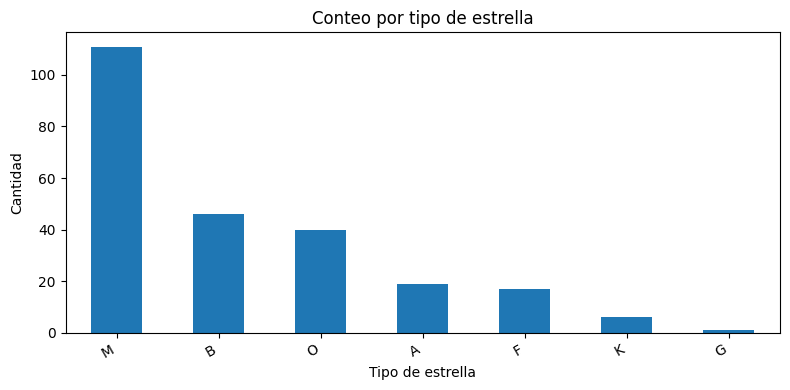

In [7]:
plt.figure(figsize=(8, 4))

# Crea la gráfica de barras con conteo.plot(kind='bar', color=..., edgecolor=...)
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
conteo.plot(kind='bar')

# Agrega título y etiquetas de ejes
plt.title('Conteo por tipo de estrella')
plt.xlabel('Tipo de estrella')
plt.ylabel('Cantidad')

plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

---
## 5. Temperatura por tipo de estrella

En esta sección calcularás la temperatura media de dos formas distintas para comparar.

**Celda 5a — Ciclo `for` (enfoque manual):**

Primero filtra el DataFrame para obtener solo las estrellas de tipo `'A7V'`:
```python
filtrado = stars[stars['Spectral Class'] == tipo_objetivo]
```
Luego recorre la columna `'Temperature (K)'` del DataFrame filtrado con un `for`,
acumula la `suma` y el `conteo` (`n`), y calcula la media como `suma / n`.

Consulta [cómo filtrar un DataFrame por valor](https://pandas.pydata.org/docs/getting_started/intro_tutorials/03_subset_data.html)
si necesitas orientación sobre la sintaxis de filtrado.

**Celda 5b — Pandas `.groupby()` (enfoque vectorizado):**

Usa [`.groupby()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html)
para calcular la media de **todas las clases a la vez** en una sola línea:
```python
df.groupby('columna_categorica')['columna_numerica'].mean()
```
Ordena de mayor a menor con `.sort_values(ascending=False)`. Guarda en `temp_por_tipo`.
Compara el resultado de `'A7V'` con el valor que obtuviste con el `for`.

**Celda 5c — Boxplot:**

Usa [`sns.boxplot()`](https://seaborn.pydata.org/generated/seaborn.boxplot.html) con
`data=stars`, `x='Spectral Class'`, `y='Temperature (K)'`, `order=orden`.

In [8]:
# ── Enfoque 1: ciclo for ──────────────────────────────────────────────────────
tipo_objetivo = 'A7V'

# Paso 1: filtra el DataFrame para obtener solo las estrellas de tipo_objetivo (clase espectral)
# filtrado = ...
tipo_objetivo = 'A'

filtrado = stars[stars['Spectral Class'] == tipo_objetivo]

# Paso 2: recorre filtrado['Temperature (K)'] con un for
# acumula la suma y el conteo (n)
suma = 0
n = 0

for temp in filtrado['Temperature (K)']:
    suma += temp
    n += 1

# Calcula la media y guárdala en media_manual
# media_manual = suma / n
media_manual = suma / n

print(f"Temperatura media (for loop) para '{tipo_objetivo}': {media_manual:.2f} K")

print(f'Temperatura media (for loop) : {media_manual:,.1f} K')

Temperatura media (for loop) para 'A': 9842.37 K
Temperatura media (for loop) : 9,842.4 K


### Comparación: `for` vs. pandas

Con el ciclo `for` calculaste la media de **una sola clase espectral** en varias líneas.
Ahora verás cómo pandas obtiene la media de **todas las clases a la vez** en una sola línea.

Cuando termines la celda 5b, verifica que el resultado de `A7V`
coincida con el valor que obtuviste con el `for`.

In [9]:
# ── Enfoque 2: pandas groupby ─────────────────────────────────────────────────
# Calcula la temperatura promedio por tipo con groupby
# Ordena de mayor a menor y guarda en temp_por_tipo
temp_por_tipo = stars.groupby('Spectral Class')['Temperature (K)'].mean()
temp_por_tipo = temp_por_tipo.sort_values(ascending=False)

print('Temperatura promedio por clase espectral (K):')
print(temp_por_tipo)
print()
# Imprime una línea de verificación comparando media_manual con el valor de groupby para 'A7V'
print("\nComparación con método manual:")
print(f"Manual (A): {media_manual:.2f} K")
print(f"Pandas (A): {temp_por_tipo['A']:.2f} K")

Temperatura promedio por clase espectral (K):
Spectral Class
O    22294.075000
B    19574.478261
A     9842.368421
F     8516.823529
G     6850.000000
K     4499.500000
M     3257.333333
Name: Temperature (K), dtype: float64


Comparación con método manual:
Manual (A): 9842.37 K
Pandas (A): 9842.37 K


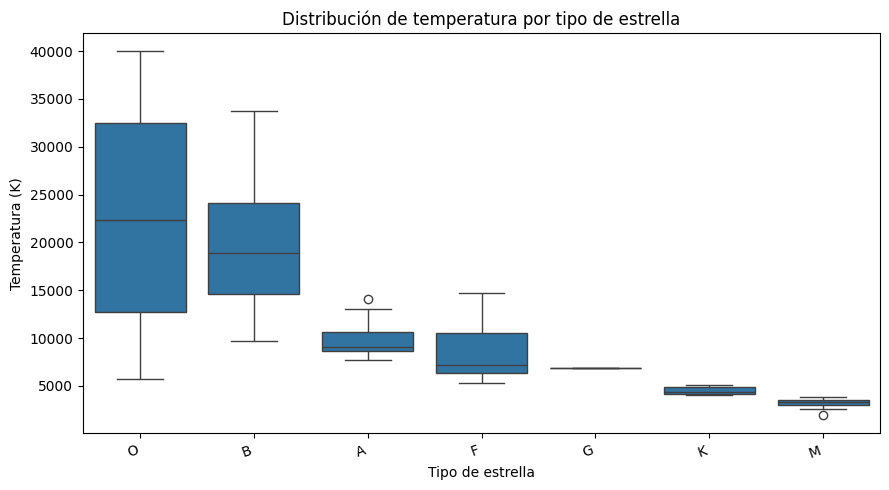

In [10]:
plt.figure(figsize=(9, 5))
orden = temp_por_tipo.index   # orden de mayor a menor temperatura

# Crea el boxplot con sns.boxplot(data=..., x=..., y=..., order=...)
sns.boxplot(
    data=stars,
    x='Spectral Class',
    y='Temperature (K)',
    order=orden
)

# Agrega título y etiquetas de ejes
plt.title('Distribución de temperatura por tipo de estrella')
plt.xlabel('Tipo de estrella')
plt.ylabel('Temperatura (K)')

plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

---
## 6. Luminosidad vs Temperatura

La luminosidad varía en muchos órdenes de magnitud (de 0.00008 a 849 420 L/Lo),
por eso necesitamos **escala logarítmica** en el eje Y.

Usa [`sns.scatterplot()`](https://seaborn.pydata.org/generated/seaborn.scatterplot.html)
con los siguientes parámetros (revisa la documentación para entender cada uno):
- `data=stars` — el DataFrame
- `x='Temperature (K)'` — temperatura en el eje X
- `y='Luminosity (L/Lo)'` — luminosidad en el eje Y
- `hue='Spectral Class'` — colorea los puntos según la clase espectral
- `style='Spectral Class'` — usa un marcador diferente por clase espectral
- `s=60` — tamaño de los puntos

Después de crear el plot, aplica escala logarítmica al eje Y con
[`plt.yscale('log')`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.yscale.html).

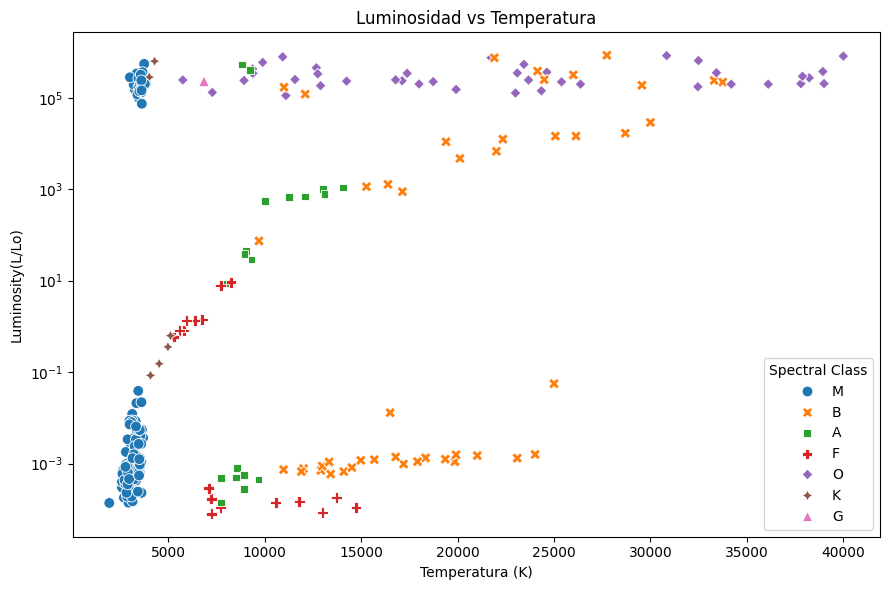

In [11]:
plt.figure(figsize=(9, 6))

# Crea el scatter plot con sns.scatterplot(...)
sns.scatterplot(
    data=stars,
    x='Temperature (K)',
    y='Luminosity(L/Lo)',
    hue='Spectral Class',
    style='Spectral Class',
    s=60
)

# Aplica escala logarítmica al eje Y
plt.yscale('log')

# Agrega título, etiquetas de ejes y leyenda
plt.title('Luminosidad vs Temperatura')
plt.xlabel('Temperatura (K)')
plt.ylabel('Luminosity(L/Lo)')

plt.tight_layout()
plt.show()

---
## 7. Estadísticas con NumPy

NumPy opera sobre **arrays completos** sin ciclos `for`. Por ejemplo,
`np.mean(arr)` calcula la media de todos los elementos de `arr` de una sola vez.

**Celda 7a** — Extrae los arrays con `.values` y calcula estadísticas:
- Extrae: `temperaturas = stars['Temperature (K)'].values`
- Extrae: `radios = stars['Radius (R/Ro)'].values`
- Verifica el tipo con `type(temperaturas)`
- Calcula usando estas funciones de [`numpy.statistics`](https://numpy.org/doc/stable/reference/routines.statistics.html):
  - [`np.mean(arr)`](https://numpy.org/doc/stable/reference/generated/numpy.mean.html) — media
  - [`np.median(arr)`](https://numpy.org/doc/stable/reference/generated/numpy.median.html) — mediana
  - [`np.std(arr)`](https://numpy.org/doc/stable/reference/generated/numpy.std.html) — desviación estándar
  - [`np.min(arr)`](https://numpy.org/doc/stable/reference/generated/numpy.amin.html) y [`np.max(arr)`](https://numpy.org/doc/stable/reference/generated/numpy.amax.html)

**Celda 7b** — Percentiles y conversión vectorizada:
- Usa [`np.percentile(arr, q)`](https://numpy.org/doc/stable/reference/generated/numpy.percentile.html)
  con `q=[25, 50, 75, 90]` para calcular los 4 percentiles de `radios` de una vez
- Convierte `temperaturas` de Kelvin a Celsius **sin usar ciclo `for`**:
  `celsius = temperaturas - 273.15` (operación vectorizada)

In [12]:
# Extrae los arrays NumPy con .values
temperaturas = stars['Temperature (K)'].values
radios = stars['Radius(R/Ro)'].values

# Imprime el tipo del array
print(type(temperaturas))

# Calcula e imprime: media, mediana, desv. estándar, mínima y máxima de temperaturas
print("Media:", np.mean(temperaturas))
print("Mediana:", np.median(temperaturas))
print("Desviación estándar:", np.std(temperaturas))
print("Mínimo:", np.min(temperaturas))
print("Máximo:", np.max(temperaturas))

<class 'numpy.ndarray'>
Media: 10497.4625
Mediana: 5776.0
Desviación estándar: 9532.503378280391
Mínimo: 1939
Máximo: 40000


In [13]:
niveles = [25, 50, 75, 90]

# Calcula los percentiles del radio estelar con np.percentile(radios, niveles)
p = np.percentile(radios, niveles)

# Imprime cada percentil usando un ciclo for y zip(niveles, p)
for nivel, valor in zip(niveles, p):
    print(f"Percentil {nivel}: {valor:.2f}")

# Convierte temperaturas de Kelvin a Celsius de forma vectorizada (sin for)
# celsius = ...
celsius = temperaturas - 273.15


# Imprime las primeras 5 temperaturas en K y en C para comparar
# (usa np.round para redondear a 1 decimal)
print("Primeras 5 temperaturas:")
for k, c in zip(temperaturas[:5], celsius[:5]):
    print(f"{k:.1f} K = {c:.1f} °C")

Percentil 25: 0.10
Percentil 50: 0.76
Percentil 75: 42.75
Percentil 90: 1315.90
Primeras 5 temperaturas:
3068.0 K = 2794.8 °C
3042.0 K = 2768.8 °C
2600.0 K = 2326.8 °C
2800.0 K = 2526.8 °C
1939.0 K = 1665.8 °C


---
## 8. Diagrama Hertzsprung-Russell

El diagrama H-R es el gráfico más importante en astronomía estelar.
Relaciona temperatura con luminosidad y revela la estructura evolutiva de las estrellas.

Este diagrama tiene **dos particularidades** que debes implementar:
1. **Ambos ejes logarítmicos**: `plt.xscale('log')` y `plt.yscale('log')`
2. **Eje X invertido** (las más calientes a la izquierda): `plt.gca().invert_xaxis()`

**Estructura del código** (el inicio ya está dado, completa las partes marcadas):

```python
tipos   = stars['Spectral Class'].unique()
colores = sns.color_palette('tab10', len(tipos))   # paleta de colores
mapa    = dict(zip(tipos, colores))                # tipo -> color

for tipo, grupo in stars.groupby('Spectral Class'):
    plt.scatter(grupo['Temperature (K)'],
                grupo['Luminosity (L/Lo)'],
                label=tipo, color=mapa[tipo], s=40, alpha=0.8)
```

Parámetros de [`plt.scatter()`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html)
que debes entender: `x`, `y`, `label`, `color`, `s` (tamaño), `alpha` (transparencia).

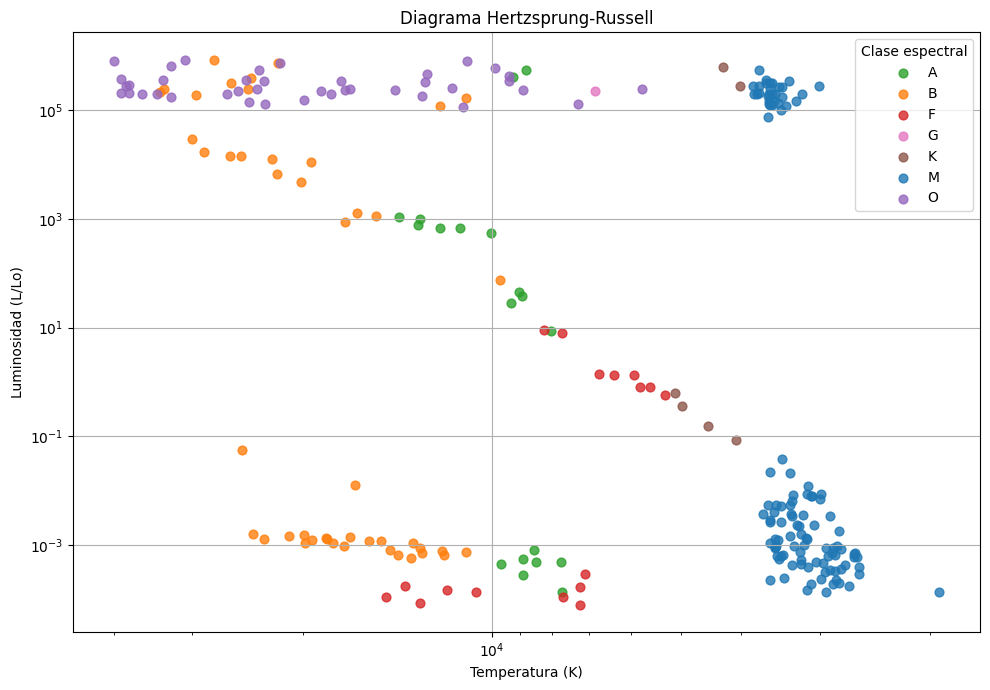

In [14]:
tipos   = stars['Spectral Class'].unique()
colores = sns.color_palette('tab10', len(tipos))
mapa    = dict(zip(tipos, colores))

plt.figure(figsize=(10, 7))

# Itera con stars.groupby('Spectral Class') y crea un plt.scatter() por cada tipo
for tipo, grupo in stars.groupby('Spectral Class'):
    plt.scatter(
        grupo['Temperature (K)'],
        grupo['Luminosity(L/Lo)'],  # ⚠️ verifica nombre exacto
        label=tipo,
        color=mapa[tipo],
        s=40,
        alpha=0.8
    )

# Aplica escala logarítmica en ambos ejes (xscale y yscale)
plt.xscale('log')
plt.yscale('log')

# Invierte el eje X con plt.gca().invert_xaxis()
plt.gca().invert_xaxis()

# Agrega: título, etiquetas de ejes, leyenda y grid
plt.title('Diagrama Hertzsprung-Russell')
plt.xlabel('Temperatura (K)')
plt.ylabel('Luminosidad (L/Lo)')

plt.legend(title='Clase espectral')
plt.grid(True)

plt.tight_layout()
plt.show()